# High-Resolution Spatial-Ensemble Quantum Variational Framework for Brain Tumor Classification

This notebook implements a complete research benchmark on the **Cheng Figshare Brain Tumor Dataset** (3,064 T1-weighted contrast-enhanced MRI slices).
It compares 7 different deep learning and hybrid quantum-classical convolutional architectures:

1. **Classical CNN**: A simple custom CNN baseline.
2. **VGG CNN**: Pre-trained classical VGG-19 backbone.
3. **ResNet CNN**: Pre-trained classical ResNet-50 backbone.
4. **DenseNet CNN**: Pre-trained classical DenseNet-121 backbone (base paper's classical benchmark).
5. **Ensemble CNN**: Fused ResNet-50 and VGG-19 backbones using 2D Convolution Stacking.
6. **Normal Quantum CNN (HQC-CNN)**: Replicates the base paper's quantum model using a custom CNN frontend and a PennyLane-based variational quantum circuit.
7. **Ensemble QCNN (Proposed Model)**: Fuses ResNet-50 and VGG-19 features using 2D Convolution Stacking and maps them to a 4-qubit variational quantum circuit.

**Base Paper Reference**: *Investigating Hybrid Quantum-Assisted Classical and Deep Learning Model for MRI Brain Tumor Classification* (Anandhavalli Muniasamy et al., JOIG 2025).

In [1]:
# Install PennyLane for Quantum Machine Learning
!pip install pennylane --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 52.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 64.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 59.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 83.4 MB/s eta 0:00:00:00:0100:01


## 1. Imports and System Configuration

In [2]:
import os
import zipfile
import urllib.request
import numpy as np
import scipy.io as sio
from PIL import Image
import shutil
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_fscore_support

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models

import pennylane as qml

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Dataset Preprocessing from Kaggle Input

This code strictly scans `/kaggle/input` for the Cheng dataset. It supports both already-unzipped `.mat` folders and the 4 raw `.zip` files, extracting them programmatically to `/kaggle/working` if needed.

In [3]:
import os
import zipfile
import urllib.request
import numpy as np
import scipy.io as sio
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit
import shutil
import h5py

# Configurations
DATASET_URL = "https://figshare.com/ndownloader/articles/1512427/versions/3"
DOWNLOAD_DIR = "dataset_raw"
ZIP_FILE_NAME = "1512427.zip"
OUTPUT_DIR = "dataset_processed"

def download_dataset():
    """Downloads the Cheng Figshare brain tumor dataset if not already present."""
    os.makedirs(DOWNLOAD_DIR, exist_ok=True)
    zip_path = os.path.join(DOWNLOAD_DIR, ZIP_FILE_NAME)
    
    if os.path.exists(zip_path):
        print(f"[*] Zip file '{zip_path}' already exists. Skipping download.")
        return zip_path
        
    print(f"[*] Downloading Cheng Figshare dataset from: {DATASET_URL}...")
    try:
        opener = urllib.request.build_opener()
        opener.addheaders = [('User-agent', 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)')]
        urllib.request.install_opener(opener)
        
        def report_hook(block_num, block_size, total_size):
            read_so_far = block_num * block_size
            if total_size > 0:
                percent = read_so_far * 100 / total_size
                print(f"\rDownloading: {percent:.1f}% ({read_so_far / (1024*1024):.1f} MB of {total_size / (1024*1024):.1f} MB)", end="")
            else:
                print(f"\rDownloading: {read_so_far / (1024*1024):.1f} MB", end="")
        
        urllib.request.urlretrieve(DATASET_URL, zip_path, reporthook=report_hook)
        print("\n[+] Download completed successfully.")
        return zip_path
    except Exception as e:
        print(f"\n[-] Error downloading dataset: {e}")
        print("[!] Please download the zip file manually from https://doi.org/10.6084/m9.figshare.1512427")
        print(f"[!] Save it as '{ZIP_FILE_NAME}' inside the '{DOWNLOAD_DIR}' directory.")
        return None

def extract_dataset(zip_path):
    """Extracts the main zip and the nested zips containing MAT files."""
    if not zip_path or not os.path.exists(zip_path):
        print("[-] Extraction failed: zip file path is invalid.")
        return None
        
    temp_extract_dir = os.path.join(DOWNLOAD_DIR, "extracted_temp")
    os.makedirs(temp_extract_dir, exist_ok=True)
    
    print("[*] Extracting main zip file...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(temp_extract_dir)
        
    nested_zips = [
        "brainTumorDataPublic_1-766.zip",
        "brainTumorDataPublic_767-1532.zip",
        "brainTumorDataPublic_1533-2298.zip",
        "brainTumorDataPublic_2299-3064.zip"
    ]
    
    mat_output_dir = os.path.join(DOWNLOAD_DIR, "mat_files")
    os.makedirs(mat_output_dir, exist_ok=True)
    
    has_nested = False
    for nz in nested_zips:
        nz_path = os.path.join(temp_extract_dir, nz)
        if os.path.exists(nz_path):
            has_nested = True
            print(f"[*] Extracting nested zip: {nz}...")
            with zipfile.ZipFile(nz_path, 'r') as zip_ref:
                zip_ref.extractall(mat_output_dir)
                
    if has_nested:
        shutil.rmtree(temp_extract_dir)
        print(f"[+] All MAT files extracted to: {mat_output_dir}")
        return mat_output_dir
    else:
        # If there were no nested zips, it means the main zip contained the MAT files directly
        mat_files = []
        for root, dirs, files in os.walk(temp_extract_dir):
            for f in files:
                if f.endswith(".mat"):
                    mat_files.append(os.path.join(root, f))
        if len(mat_files) > 0:
            from collections import Counter
            folders = [os.path.dirname(f) for f in mat_files]
            mat_dir = Counter(folders).most_common(1)[0][0]
            print(f"[+] MAT files found directly in extracted zip: {mat_dir}")
            return mat_dir
            
    return None

def extract_mat_metadata(file_path):
    """Extracts ONLY label and patient ID from a MAT file to avoid reading heavy image matrices."""
    try:
        with h5py.File(file_path, 'r') as f:
            if 'cjdata' in f:
                cjdata = f['cjdata']
                label = int(np.array(cjdata['label']).flatten()[0])
                pid_arr = np.array(cjdata['PID']).flatten()
                if pid_arr.dtype.kind in ['U', 'S']:
                    pid = "".join([s.decode('utf-8') if isinstance(s, bytes) else str(s) for s in pid_arr]).strip()
                else:
                    pid = "".join(chr(int(c)) for c in pid_arr if c > 0).strip()
            else:
                label = int(np.array(f['label']).flatten()[0])
                pid_arr = np.array(f['PID']).flatten()
                if pid_arr.dtype.kind in ['U', 'S']:
                    pid = "".join([s.decode('utf-8') if isinstance(s, bytes) else str(s) for s in pid_arr]).strip()
                else:
                    pid = "".join(chr(int(c)) for c in pid_arr if c > 0).strip()
            if not pid:
                pid = "unknown"
            return label, pid
    except Exception as e_h5py:
        try:
            mat_data = sio.loadmat(file_path, variable_names=['cjdata'])
            if 'cjdata' in mat_data:
                cjdata = mat_data['cjdata'][0, 0]
            else:
                cjdata = mat_data
                
            if hasattr(cjdata, 'dtype') and 'label' in cjdata.dtype.names:
                label = int(cjdata['label'].flatten()[0])
            elif 'label' in cjdata:
                label = int(cjdata['label'].flatten()[0])
            else:
                raise KeyError("Could not find 'label' field.")
                
            if hasattr(cjdata, 'dtype') and 'PID' in cjdata.dtype.names:
                pid_arr = cjdata['PID']
            elif 'PID' in cjdata:
                pid_arr = cjdata['PID']
            else:
                pid_arr = "unknown"
                
            if isinstance(pid_arr, np.ndarray):
                if pid_arr.dtype.kind in ['i', 'u']:
                    pid = "".join([chr(int(c)) for c in pid_arr.flatten() if c > 0]).strip()
                else:
                    pid = "".join([str(c) for c in pid_arr.flatten()]).strip()
            else:
                pid = str(pid_arr).strip()
                
            if not pid:
                pid = "unknown"
                
            return label, pid
        except Exception as e_sio:
            raise ValueError(f"Failed to read metadata. h5py error: {e_h5py}; scipy error: {e_sio}")

def extract_mat_data(file_path):
    """Extracts image, label, and patient ID from a MAT file supporting Matlab 7.3 (h5py) or older (scipy.io.loadmat)."""
    try:
        with h5py.File(file_path, 'r') as f:
            if 'cjdata' in f:
                cjdata = f['cjdata']
                image = np.array(cjdata['image']).T
                label = int(np.array(cjdata['label']).flatten()[0])
                
                pid_arr = np.array(cjdata['PID']).flatten()
                if pid_arr.dtype.kind in ['U', 'S']:
                    pid = "".join([s.decode('utf-8') if isinstance(s, bytes) else str(s) for s in pid_arr]).strip()
                else:
                    pid = "".join(chr(int(c)) for c in pid_arr if c > 0).strip()
            else:
                image = np.array(f['image']).T
                label = int(np.array(f['label']).flatten()[0])
                pid_arr = np.array(f['PID']).flatten()
                if pid_arr.dtype.kind in ['U', 'S']:
                    pid = "".join([s.decode('utf-8') if isinstance(s, bytes) else str(s) for s in pid_arr]).strip()
                else:
                    pid = "".join(chr(int(c)) for c in pid_arr if c > 0).strip()
            
            if not pid:
                pid = "unknown"
            return image, label, pid
    except Exception as e_h5py:
        try:
            mat_data = sio.loadmat(file_path)
            if 'cjdata' in mat_data:
                cjdata = mat_data['cjdata'][0, 0]
            else:
                cjdata = mat_data
                
            if hasattr(cjdata, 'dtype') and 'label' in cjdata.dtype.names:
                label = int(cjdata['label'].flatten()[0])
            elif 'label' in cjdata:
                label = int(cjdata['label'].flatten()[0])
            else:
                raise KeyError("Could not find 'label' field.")
                
            if hasattr(cjdata, 'dtype') and 'PID' in cjdata.dtype.names:
                pid_arr = cjdata['PID']
            elif 'PID' in cjdata:
                pid_arr = cjdata['PID']
            else:
                pid_arr = "unknown"
                
            if isinstance(pid_arr, np.ndarray):
                if pid_arr.dtype.kind in ['i', 'u']:
                    pid = "".join([chr(int(c)) for c in pid_arr.flatten() if c > 0]).strip()
                else:
                    pid = "".join([str(c) for c in pid_arr.flatten()]).strip()
            else:
                pid = str(pid_arr).strip()
                
            if not pid:
                pid = "unknown"
                
            if hasattr(cjdata, 'dtype') and 'image' in cjdata.dtype.names:
                image = cjdata['image']
            elif 'image' in cjdata:
                image = cjdata['image']
            else:
                raise KeyError("Could not find 'image' field.")
                
            return image, label, pid
        except Exception as e_sio:
            raise ValueError(f"Failed to read MAT file. h5py error: {e_h5py}; scipy error: {e_sio}")

def process_mat_files(mat_files_or_dir):
    """Parses MAT files, performs patient-grouped splits, and saves PNGs by class."""
    print("[*] process_mat_files: Initializing MAT processor...")
    if isinstance(mat_files_or_dir, str):
        if not os.path.exists(mat_files_or_dir):
            print(f"[-] process_mat_files failed: Directory {mat_files_or_dir} not found.")
            return
        mat_files = [os.path.join(mat_files_or_dir, f) for f in os.listdir(mat_files_or_dir) if f.endswith(".mat")]
    else:
        mat_files = [f for f in mat_files_or_dir if f.endswith(".mat")]
        
    print(f"[+] process_mat_files: Found {len(mat_files)} MAT files. Starting MAT validation (metadata extraction)...")
    
    labels = []
    pids = []
    file_paths = []
    
    for i, file_path in enumerate(mat_files):
        try:
            label, pid = extract_mat_metadata(file_path)
            labels.append(label)
            pids.append(pid)
            file_paths.append(file_path)
            if (i + 1) % 500 == 0 or (i + 1) == len(mat_files):
                print(f"  - Successfully extracted metadata for {i + 1}/{len(mat_files)} MAT files...")
        except Exception as e:
            print(f"  [-] Error reading MAT file {os.path.basename(file_path)}: {e}")
            
    print(f"[+] process_mat_files: Validation complete. Parsed {len(file_paths)}/{len(mat_files)} MAT files.")
    if len(file_paths) == 0:
        raise ValueError("No MAT files could be parsed. All files failed to load.")
        
    labels = np.array(labels)
    pids = np.array(pids)
    file_paths = np.array(file_paths)
    
    print("[*] process_mat_files: Mapping labels...")
    if labels.min() == 1:
        print(f"    - Meningioma (Class 1): {np.sum(labels == 1)}")
        print(f"    - Glioma (Class 2): {np.sum(labels == 2)}")
        print(f"    - Pituitary (Class 3): {np.sum(labels == 3)}")
        labels = labels - 1
    else:
        print(f"    - Meningioma (Class 0): {np.sum(labels == 0)}")
        print(f"    - Glioma (Class 1): {np.sum(labels == 1)}")
        print(f"    - Pituitary (Class 2): {np.sum(labels == 2)}")
    print(f"    - Total patients: {len(np.unique(pids))}")
    
    from sklearn.model_selection import train_test_split
    print("[*] process_mat_files: Performing patient-grouped stratified train/val/test splits (70/10/20)...")
    
    # Extract unique patient IDs and their corresponding diagnosis labels
    unique_pids, unique_indices = np.unique(pids, return_index=True)
    patient_labels = labels[unique_indices]
    
    print(f"    - Total unique patients: {len(unique_pids)}")
    print(f"    - Patient-level label distribution:")
    print(f"      - Meningioma (Class 0): {np.sum(patient_labels == 0)}")
    print(f"      - Glioma (Class 1): {np.sum(patient_labels == 1)}")
    print(f"      - Pituitary (Class 2): {np.sum(patient_labels == 2)}")
    
    # Split patient IDs into train, val, and test splits (70/10/20) while stratifying on patient diagnosis
    train_pids, temp_pids, _, temp_pat_lbls = train_test_split(
        unique_pids, patient_labels, test_size=0.3, random_state=42, stratify=patient_labels
    )
    val_pids, test_pids, _, _ = train_test_split(
        temp_pids, temp_pat_lbls, test_size=0.6667, random_state=42, stratify=temp_pat_lbls
    )
    
    # Map back from patient IDs to slice files and slice labels
    train_mask = np.isin(pids, train_pids)
    val_mask = np.isin(pids, val_pids)
    test_mask = np.isin(pids, test_pids)
    
    train_files = file_paths[train_mask]
    train_lbls = labels[train_mask]
    val_files = file_paths[val_mask]
    val_lbls = labels[val_mask]
    test_files = file_paths[test_mask]
    test_lbls = labels[test_mask]
    
    splits = {
        'train': (train_files, train_lbls),
        'val': (val_files, val_lbls),
        'test': (test_files, test_lbls)
    }
    
    print(f"    - Train split size: {len(train_files)} slices (from {len(train_pids)} patients)")
    print(f"    - Val split size: {len(val_files)} slices (from {len(val_pids)} patients)")
    print(f"    - Test split size: {len(test_files)} slices (from {len(test_pids)} patients)")
    
    class_names = {0: "meningioma", 1: "glioma", 2: "pituitary"}
    
    print("[*] process_mat_files: Creating folder structure under output directory...")
    if os.path.exists(OUTPUT_DIR):
        try:
            shutil.rmtree(OUTPUT_DIR)
            print(f"[+] Cleared old output directory: {OUTPUT_DIR}")
        except Exception as e:
            print(f"[-] Warning: Failed to clean old OUTPUT_DIR: {e}")
        
    for split in ['train', 'val', 'test']:
        for label_idx in class_names.values():
            os.makedirs(os.path.join(OUTPUT_DIR, split, label_idx), exist_ok=True)
            
    print("[*] process_mat_files: Exporting MAT image matrices to PNG...")
    for split_name, (paths, lbls) in splits.items():
        print(f"  - Converting '{split_name}' split ({len(paths)} images)...")
        for idx, (path, lbl) in enumerate(zip(paths, lbls)):
            try:
                img, _, _ = extract_mat_data(path)
                img = img.astype(np.float32)
                
                img_min, img_max = img.min(), img.max()
                if img_max > img_min:
                    img_norm = 255.0 * (img - img_min) / (img_max - img_min)
                else:
                    img_norm = img * 0
                img_norm = img_norm.astype(np.uint8)
                
                pil_img = Image.fromarray(img_norm)
                class_folder = class_names[lbl]
                file_id = os.path.basename(path).replace(".mat", ".png")
                save_path = os.path.join(OUTPUT_DIR, split_name, class_folder, file_id)
                pil_img.save(save_path)
                
                if (idx + 1) % 200 == 0 or (idx + 1) == len(paths):
                    print(f"    - [{split_name}] Converted and saved {idx + 1}/{len(paths)} PNGs...")
            except Exception as e:
                print(f"    [-] Error converting image {os.path.basename(path)}: {e}")
                
    final_count = 0
    for root, dirs, files in os.walk(OUTPUT_DIR):
        final_count += sum(1 for f in files if f.endswith(".png"))
    print(f"[+] process_mat_files: Successfully exported {final_count} PNG files to {OUTPUT_DIR}.")

def find_and_process_input(force_clear=False):
    import os
    import zipfile
    import shutil
    from collections import Counter
    
    print("[*] STEP 1: Initializing find_and_process_input...")
    input_dir = "/kaggle/input"
    if not os.path.exists(input_dir):
        input_dir = "."
    print(f"[*] STEP 2: Input directory set to: {input_dir}")
    
    global OUTPUT_DIR
    OUTPUT_DIR = "dataset_processed"
    print(f"[*] STEP 3: Output directory set to: {OUTPUT_DIR}")
    
    # Check if dataset is already preprocessed and complete
    if not force_clear and os.path.exists(OUTPUT_DIR):
        png_count = 0
        for root, dirs, files in os.walk(OUTPUT_DIR):
            png_count += sum(1 for f in files if f.endswith(".png"))
        if png_count >= 3000:
            print(f"[+] STEP 4: Found {png_count} already preprocessed PNG files in {OUTPUT_DIR}. Skipping preprocessing to save time.")
            return
            
    # Force clearing the cache if requested or if incomplete
    print("[*] STEP 4: Clearing/resetting processed dataset cache...")
    if os.path.exists(OUTPUT_DIR):
        try:
            shutil.rmtree(OUTPUT_DIR)
            print("[+] Successfully cleared existing dataset_processed folder.")
        except Exception as e:
            print(f"[-] Warning: Failed to delete {OUTPUT_DIR}: {e}")
    else:
        print("[*] No existing dataset_processed folder found. Ready for a clean run.")
        
    print("[*] STEP 5: Scanning input directory recursively for Cheng dataset (up to depth 5)...")
    mat_files = []
    zip_files = []
    
    base_depth = os.path.abspath(input_dir).count(os.sep)
    for root, dirs, files in os.walk(input_dir):
        # Skip hidden and output directories
        dirs[:] = [d for d in dirs if d not in ['__pycache__', '.git', 'output', 'outputs', 'dataset_processed']]
        
        # Limit depth to 5
        depth = os.path.abspath(root).count(os.sep) - base_depth
        if depth >= 5:
            dirs[:] = []
            
        for f in files:
            path = os.path.join(root, f)
            if f.endswith(".mat"):
                name_part = f[:-4]
                # Check if it is a numeric filename between 1 and 3064
                if name_part.isdigit() and 1 <= int(name_part) <= 3064:
                    mat_files.append(path)
            elif f.endswith(".zip"):
                zip_files.append(path)
                
        # Early exit if we found the complete dataset (3064 slices)
        if len(mat_files) >= 3064:
            print(f"  - Found all {len(mat_files)} Cheng dataset MAT files. Stopping scan early.")
            break
            
    print(f"[*] STEP 6: Scan complete. Found {len(mat_files)} matching Cheng MAT files and {len(zip_files)} total ZIP files.")
    
    if len(mat_files) >= 3000:
        print(f"[+] STEP 7: Unzipped Cheng dataset detected ({len(mat_files)} files). Starting processing...")
        process_mat_files(mat_files)
        return
        
    if len(zip_files) > 0:
        print("[*] STEP 7: Zip files detected. Identifying Cheng dataset main zip...")
        main_zip = None
        for z in zip_files:
            try:
                print(f"  - Checking zip contents: {z}...")
                with zipfile.ZipFile(z, 'r') as zf:
                    names = zf.namelist()
                    if any("brainTumorDataPublic" in n for n in names) or any(n.endswith(".mat") for n in names):
                        main_zip = z
                        print(f"    [+] Found Cheng dataset zip: {z}")
                        break
            except Exception as e:
                print(f"    [-] Error checking zip {z}: {e}")
                pass
                
        if main_zip:
            print(f"[+] STEP 8: Extracting main dataset zip: {main_zip}...")
            mat_dir = extract_dataset(main_zip)
            if mat_dir:
                mat_files_extracted = []
                for root, dirs, files in os.walk(mat_dir):
                    for f in files:
                        if f.endswith(".mat"):
                            name_part = f[:-4]
                            if name_part.isdigit() and 1 <= int(name_part) <= 3064:
                                mat_files_extracted.append(os.path.join(root, f))
                print(f"[+] Extracted {len(mat_files_extracted)} MAT files. Starting processing...")
                process_mat_files(mat_files_extracted)
                return
            else:
                print("[-] Error: Extraction failed to return a MAT directory.")
        else:
            public_zips = [z for z in zip_files if "brainTumorDataPublic" in os.path.basename(z)]
            if len(public_zips) > 0:
                print(f"[+] STEP 8: Found {len(public_zips)} public brain tumor zip segments directly. Extracting...")
                temp_extract = "mat_files_temp"
                if os.path.exists(temp_extract):
                    shutil.rmtree(temp_extract)
                os.makedirs(temp_extract, exist_ok=True)
                for z in public_zips:
                    print(f"  - Extracting nested zip segment: {z}...")
                    with zipfile.ZipFile(z, 'r') as zip_ref:
                        zip_ref.extractall(temp_extract)
                mat_files_extracted = []
                for root, dirs, files in os.walk(temp_extract):
                    for f in files:
                        if f.endswith(".mat"):
                            name_part = f[:-4]
                            if name_part.isdigit() and 1 <= int(name_part) <= 3064:
                                mat_files_extracted.append(os.path.join(root, f))
                print(f"[+] Extracted {len(mat_files_extracted)} MAT files in temp folder. Starting processing...")
                process_mat_files(mat_files_extracted)
                shutil.rmtree(temp_extract)
                return

    raise ValueError("Cheng dataset not found in input directory! Please attach the Cheng Figshare brain tumor dataset to your Kaggle notebook.")


if __name__ == '__main__':
    find_and_process_input(force_clear=True)


[*] STEP 1: Initializing find_and_process_input...
[*] STEP 2: Input directory set to: /kaggle/input
[*] STEP 3: Output directory set to: dataset_processed
[*] STEP 4: Clearing/resetting processed dataset cache...
[*] No existing dataset_processed folder found. Ready for a clean run.
[*] STEP 5: Scanning input directory recursively for Cheng dataset (up to depth 5)...
  - Found all 3064 Cheng dataset MAT files. Stopping scan early.
[*] STEP 6: Scan complete. Found 3064 matching Cheng MAT files and 0 total ZIP files.
[+] STEP 7: Unzipped Cheng dataset detected (3064 files). Starting processing...
[*] process_mat_files: Initializing MAT processor...
[+] process_mat_files: Found 3064 MAT files. Starting MAT validation (metadata extraction)...
  - Successfully extracted metadata for 500/3064 MAT files...
  - Successfully extracted metadata for 1000/3064 MAT files...
  - Successfully extracted metadata for 1500/3064 MAT files...
  - Successfully extracted metadata for 2000/3064 MAT files...

## 3. Model Architecture Definitions

In [4]:
import torch
import torch.nn as nn
import torchvision.models as models
import pennylane as qml

# --- Backbones with Backward Compatibility ---
def get_vgg19():
    try:
        return models.vgg19(weights=models.VGG19_Weights.DEFAULT)
    except AttributeError:
        return models.vgg19(pretrained=True)

def get_resnet50():
    try:
        return models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    except AttributeError:
        return models.resnet50(pretrained=True)

def get_densenet121():
    try:
        return models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    except AttributeError:
        return models.densenet121(pretrained=True)


# --- 1. Classical Custom CNN Baseline ---
class ClassicalCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 112x112
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 56x56
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 28x28
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 14x14
            
            nn.AdaptiveAvgPool2d((1, 1)) # 256x1x1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        features = self.features(x)
        logits = self.classifier(features)
        return logits


# --- 2. VGG CNN (Pre-trained classical backbone) ---
class VGGCNN(nn.Module):
    def __init__(self, num_classes=3, mode='fine_tune'):
        super().__init__()
        vgg = get_vgg19()
        
        if mode == 'freeze':
            for param in vgg.parameters():
                param.requires_grad = False
        elif mode == 'fine_tune':
            for param in vgg.parameters():
                param.requires_grad = False
            # Unfreeze block 5 of VGG-19 features (layers 28 to 36)
            for param in vgg.features[28:].parameters():
                param.requires_grad = True
        else:  # 'unfreeze'
            pass  # Keep all parameters trainable
            
        self.features = vgg.features
        self.avgpool = vgg.avgpool
        
        # Replace VGG classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        logits = self.classifier(x)
        return logits


# --- 3. ResNet CNN (Pre-trained classical backbone) ---
class ResNetCNN(nn.Module):
    def __init__(self, num_classes=3, mode='fine_tune'):
        super().__init__()
        resnet = get_resnet50()
        
        if mode == 'freeze':
            for param in resnet.parameters():
                param.requires_grad = False
        elif mode == 'fine_tune':
            for param in resnet.parameters():
                param.requires_grad = False
            # Unfreeze residual block group 4 (layer4)
            for param in resnet.layer4.parameters():
                param.requires_grad = True
        else:  # 'unfreeze'
            pass
            
        # Remove fc and avgpool
        self.features = nn.Sequential(*list(resnet.children())[:-2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        logits = self.classifier(x)
        return logits


# --- 4. DenseNet CNN (Base Paper Classical Benchmark) ---
class DenseNetCNN(nn.Module):
    def __init__(self, num_classes=3, mode='fine_tune'):
        super().__init__()
        densenet = get_densenet121()
        
        if mode == 'freeze':
            for param in densenet.parameters():
                param.requires_grad = False
        elif mode == 'fine_tune':
            for param in densenet.parameters():
                param.requires_grad = False
            # Unfreeze denseblock4 and norm5
            for param in densenet.features.denseblock4.parameters():
                param.requires_grad = True
            for param in densenet.features.norm5.parameters():
                param.requires_grad = True
        else:  # 'unfreeze'
            pass
            
        self.features = densenet.features
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        # Rescale image to 128x128 as in the base paper
        x_rescaled = torch.nn.functional.interpolate(x, size=(128, 128), mode='bilinear', align_corners=False)
        x = self.features(x_rescaled)
        x = self.avgpool(x)
        logits = self.classifier(x)
        return logits


# --- 5. Ensemble CNN (Classical ResNet + VGG Fused via Logit Ensembling) ---
class EnsembleCNN(nn.Module):
    def __init__(self, num_classes=3, mode='fine_tune'):
        super().__init__()
        resnet = get_resnet50()
        vgg = get_vgg19()
        
        if mode == 'freeze':
            for param in resnet.parameters():
                param.requires_grad = False
            for param in vgg.parameters():
                param.requires_grad = False
        elif mode == 'fine_tune':
            for param in resnet.parameters():
                param.requires_grad = False
            for param in vgg.parameters():
                param.requires_grad = False
            # Unfreeze resnet layer4 and vgg features[28:]
            for param in resnet.layer4.parameters():
                param.requires_grad = True
            for param in vgg.features[28:].parameters():
                param.requires_grad = True
        else:  # 'unfreeze'
            pass
            
        self.resnet_features = nn.Sequential(*list(resnet.children())[:-2])
        self.resnet_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.resnet_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
        self.vgg_features = vgg.features
        self.vgg_pool = vgg.avgpool
        self.vgg_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        # ResNet path
        r_feat = self.resnet_pool(self.resnet_features(x))
        r_logits = self.resnet_fc(r_feat)
        
        # VGG path
        v_feat = self.vgg_pool(self.vgg_features(x))
        v_logits = self.vgg_fc(v_feat)
        
        # Weighted average of logits: ResNet is stronger, so we give it slightly more weight (0.6 vs 0.4)
        logits = 0.6 * r_logits + 0.4 * v_logits
        return logits


# --- PennyLane QNode and PyTorch Layer Helpers ---
class QuantumConvolutionLayer(nn.Module):
    def __init__(self, n_data_qubits=4, n_ancillas=2):
        super().__init__()
        self.n_data_qubits = n_data_qubits
        self.n_ancillas = n_ancillas
        
        # Define weights directly as standard parameters (ensures optimizer tracking is never lost)
        self.weights = nn.Parameter(torch.randn(n_data_qubits, 2))
        
        total_wires = n_data_qubits + n_ancillas
        dev = qml.device("default.qubit", wires=total_wires)
        
        @qml.qnode(dev, interface="torch")
        def qnode(inputs, weights):
            # inputs shape: (4,) - representing 2x2 image patch
            # weights shape: (4, 2) - representing RX and RZ angles for quantum convolution
            
            # 1. State Preparation / Angle Embedding (using RX and RZ gates as described in the paper)
            for i in range(self.n_data_qubits):
                qml.RX(inputs[..., i], wires=i)
                qml.RZ(inputs[..., i], wires=i)
                
            # 2. Quantum Convolution (parameterized RX and RZ gates followed by CNOT entanglement)
            for i in range(self.n_data_qubits):
                qml.RX(weights[i, 0], wires=i)
                qml.RZ(weights[i, 1], wires=i)
                
            # CNOT chain for spatial neighborhood entanglement
            for i in range(self.n_data_qubits - 1):
                qml.CNOT(wires=[i, i + 1])
            qml.CNOT(wires=[self.n_data_qubits - 1, 0])
            
            # 3. SWAP-Test Based Quantum Pooling (ancillas 4 & 5)
            qml.Hadamard(wires=4)
            qml.CSWAP(wires=[4, 0, 1])
            qml.Hadamard(wires=4)
            
            qml.Hadamard(wires=5)
            qml.CSWAP(wires=[5, 2, 3])
            qml.Hadamard(wires=5)
            
            # Return the overlap similarity expectation values (pooled output: 2 features)
            return [qml.expval(qml.PauliZ(4)), qml.expval(qml.PauliZ(5))]
            
        self.qnode = qnode
        
    def forward(self, x):
        # Input shape: [batch_size, C, H, W]
        batch_size, C, H, W = x.shape
        device = x.device
        
        # Extract patches of size 2x2 with stride 2
        H_out, W_out = H // 2, W // 2
        patches = x.unfold(2, 2, 2).unfold(3, 2, 2) # [batch_size, C, H_out, W_out, 2, 2]
        
        # Reshape patches to [batch_size * C * H_out * W_out, 4]
        patches = patches.contiguous().view(-1, 4)
        
        # Scale to [-pi, pi] for angle embedding
        patches = patches * 3.14159
        
        # Copy input and weights to CPU for quantum execution
        patches_cpu = patches.cpu()
        weights_cpu = self.weights.cpu()
        
        # Run QNode manually on CPU (retains gradients and allows PyTorch autograd backprop to GPU parameters)
        res = self.qnode(patches_cpu, weights_cpu)
        if isinstance(res, list) or isinstance(res, tuple):
            out_cpu = torch.stack(res, dim=-1)
        else:
            out_cpu = res
            if out_cpu.shape[0] == 2 and len(out_cpu.shape) == 2 and out_cpu.shape[1] != 2:
                out_cpu = out_cpu.T
                
        out = out_cpu.to(device).float()
        
        # Reshape back to [batch_size, C, H_out, W_out, 2] and permute to [batch_size, C, 2, H_out, W_out]
        # Then flatten the channel dimension to C * 2
        out = out.view(batch_size, C, H_out, W_out, 2).permute(0, 1, 4, 2, 3).contiguous()
        out = out.view(batch_size, C * 2, H_out, W_out)
        return out


# --- 6. Normal Quantum CNN (Base Paper Quantum Model Replicated) ---
class NormalQuantumCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # True patch-wise quantum convolution layer
        self.q_conv_pooling = QuantumConvolutionLayer(n_data_qubits=4, n_ancillas=2)
        
        # High-capacity classifier to stabilize training, prevent underfitting, and converge to target accuracy
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 3)
        )
        
    def forward(self, x):
        # 1. Denormalize input x (range: [0, 1]) from the ImageNet mean/std
        mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1, 3, 1, 1)
        x_orig = x * std + mean
        x_orig = torch.clamp(x_orig, 0.0, 1.0)
        
        # 2. Convert to grayscale: [batch_size, 1, H, W]
        x_gray = x_orig.mean(dim=1, keepdim=True)
        
        # 3. Downsample to 64x64 bilinearly as per the base paper
        x_small = torch.nn.functional.interpolate(x_gray, size=(64, 64), mode='bilinear', align_corners=False)
        
        # 4. Quantum convolution & pooling (stride 2) -> output shape: [batch_size, 2, 32, 32]
        q_feat = self.q_conv_pooling(x_small)
        
        # 5. Classifier
        logits = self.classifier(q_feat)
        return logits


# --- 7. Ensemble QCNN (Spatial-Ensemble Quantum Framework via Late Fusion Projection & Skip Connection) ---
class EnsembleQCNN(nn.Module):
    def __init__(self, mode='fine_tune'):
        super().__init__()
        resnet = get_resnet50()
        vgg = get_vgg19()
        
        if mode == 'freeze':
            for param in resnet.parameters():
                param.requires_grad = False
            for param in vgg.parameters():
                param.requires_grad = False
        elif mode == 'fine_tune':
            for param in resnet.parameters():
                param.requires_grad = False
            for param in vgg.parameters():
                param.requires_grad = False
            # Unfreeze resnet layer4 and vgg features[28:]
            for param in resnet.layer4.parameters():
                param.requires_grad = True
            for param in vgg.features[28:].parameters():
                param.requires_grad = True
        else:  # 'unfreeze'
            pass
            
        self.resnet_features = nn.Sequential(*list(resnet.children())[:-2])
        self.vgg_features = vgg.features
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Learnable projection network from 2560 concatenated classical features
        # down to 16 features (which will be reshaped to 1x4x4 for the 4-qubit QCNN)
        self.proj = nn.Sequential(
            nn.Linear(2560, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 16)
        )
        
        # True patch-wise quantum convolution layer
        self.q_conv_pooling = QuantumConvolutionLayer(n_data_qubits=4, n_ancillas=2)
        
        # Classical skip connection mapping to align dimensions (16 classical -> 8 features)
        self.skip = nn.Linear(16, 8)
        
        # Classifier (takes 8 quantum features + 8 classical skip features = 16 features -> 3 classes)
        self.classifier = nn.Sequential(
            nn.Linear(16, 3)
        )
        
    def forward(self, x):
        r_feat = self.resnet_features(x)
        v_feat = self.vgg_features(x)
        
        r_pooled = self.avgpool(r_feat).view(x.size(0), -1)
        v_pooled = self.avgpool(v_feat).view(x.size(0), -1)
        
        # Late feature fusion
        fused = torch.cat([r_pooled, v_pooled], dim=1)
        
        # Classical projection
        projected = self.proj(fused)
        
        # Reshape to [batch_size, 1, 4, 4] for QCNN embedding
        projected_tensor = projected.view(x.size(0), 1, 4, 4)
        
        # Scale to [0, 1] for angle embedding
        projected_scaled = torch.sigmoid(projected_tensor)
        
        # Quantum convolution and pooling (outputs 8 features)
        q_feat = self.q_conv_pooling(projected_scaled) # [batch_size, 2, 2, 2]
        q_feat_flat = torch.flatten(q_feat, start_dim=1) # [batch_size, 8]
        
        # Classical skip projection (outputs 8 features)
        skip_feat = self.skip(projected) # [batch_size, 8]
        
        # Combine quantum entangled features with classical features
        combined_feat = torch.cat([q_feat_flat, skip_feat], dim=1) # [batch_size, 16]
        
        logits = self.classifier(combined_feat)
        return logits


## 4. Training and Evaluation Utilities

In [5]:


def get_dataloaders(dataset_dir, batch_size=16):
    print(f"[*] get_dataloaders: Creating PyTorch DataLoaders for {dataset_dir} (batch_size={batch_size})...")
    norm_mean, norm_std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15), transforms.ToTensor(),
        transforms.Normalize(mean=norm_mean, std=norm_std)
    ])
    val_test_transform = transforms.Compose([
        transforms.Resize((224, 224)), transforms.ToTensor(),
        transforms.Normalize(mean=norm_mean, std=norm_std)
    ])
    train_path = os.path.join(dataset_dir, 'train')
    val_path = os.path.join(dataset_dir, 'val')
    test_path = os.path.join(dataset_dir, 'test')
    print(f"  - Loading training dataset from {train_path}...")
    try:
        train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
        print(f"    [+] Loaded training dataset: {len(train_dataset)} images, classes: {train_dataset.classes}")
    except Exception as e:
        print(f"    [-] Error loading training dataset: {e}")
        raise
    print(f"  - Loading validation dataset from {val_path}...")
    try:
        val_dataset = datasets.ImageFolder(val_path, transform=val_test_transform)
        print(f"    [+] Loaded validation dataset: {len(val_dataset)} images, classes: {val_dataset.classes}")
    except Exception as e:
        print(f"    [-] Error loading validation dataset: {e}")
        raise
    print(f"  - Loading test dataset from {test_path}...")
    try:
        test_dataset = datasets.ImageFolder(test_path, transform=val_test_transform)
        print(f"    [+] Loaded test dataset: {len(test_dataset)} images, classes: {test_dataset.classes}")
    except Exception as e:
        print(f"    [-] Error loading test dataset: {e}")
        raise
    print("  - Creating PyTorch DataLoaders (num_workers=0, pin_memory=True)...")
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    print("[+] get_dataloaders: DataLoaders successfully created.")
    return train_loader, val_loader, test_loader

def train_model(name, model, train_loader, val_loader, epochs=20, lr=0.1):
    print(f"\n[*] Training {name} for {epochs} epochs (lr={lr})...")
    model = model.to(device)
    # In PyTorch, nn.CrossEntropyLoss() is the exact mathematical equivalent of Keras's
    # 'sparse_categorical_crossentropy' loss combined with a 'softmax' activation layer.
    # We keep the model outputs as raw logits (no softmax at the end) and let CrossEntropyLoss
    # compute log_softmax internally for maximum numerical stability and to prevent model collapse.
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    best_val_acc = 0.0
    early_stopping_patience = 15
    epochs_no_improve = 0
    best_weights = None
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
        train_loss = running_loss / total
        train_acc = correct / total
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_running_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total += targets.size(0)
                val_correct += predicted.eq(targets).sum().item()
        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total
        scheduler.step(val_loss)
        print(f"  Epoch [{epoch:02d}/{epochs:02d}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_no_improve = 0
            import copy
            best_weights = copy.deepcopy(model.state_dict())
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= early_stopping_patience:
                print(f"[*] Early stopping triggered at epoch {epoch}.")
                break
    if best_weights is not None:
        model.load_state_dict(best_weights)
    return model

def evaluate_model(name, model, test_loader):
    print(f"[*] Evaluating {name} on test set...")
    model.eval()
    # In PyTorch, nn.CrossEntropyLoss() is the exact mathematical equivalent of Keras's
    # 'sparse_categorical_crossentropy' loss combined with a 'softmax' activation layer.
    # We keep the model outputs as raw logits (no softmax at the end) and let CrossEntropyLoss
    # compute log_softmax internally for maximum numerical stability and to prevent model collapse.
    criterion = nn.CrossEntropyLoss()
    running_loss = 0.0
    total = 0
    all_targets = []
    all_preds = []
    all_probs = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item() * inputs.size(0)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            total += targets.size(0)
    test_loss = running_loss / total
    all_targets = np.array(all_targets)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    precision, recall, fscore, _ = precision_recall_fscore_support(all_targets, all_preds, average='macro')
    test_acc = np.mean(all_targets == all_preds)
    metrics = {
        'model': name,
        'test_loss': float(test_loss),
        'test_accuracy': float(test_acc),
        'macro_precision': float(precision),
        'macro_recall': float(recall),
        'macro_f1': float(fscore)
    }
    # Print metrics immediately to console/notebook output
    print(f"\n[+] Evaluation Results for {name}:")
    print(f"    - Test Loss:      {test_loss:.4f}")
    print(f"    - Test Accuracy:  {test_acc * 100:.2f}%")
    print(f"    - Macro Precision: {precision * 100:.2f}%")
    print(f"    - Macro Recall:    {recall * 100:.2f}%")
    print(f"    - Macro F1-Score:  {fscore * 100:.2f}%")
    # Print detailed class-level report
    from sklearn.metrics import classification_report
    print("\nDetailed Classification Report:")
    print(classification_report(all_targets, all_preds, target_names=["Meningioma", "Glioma", "Pituitary"], digits=4))
    return metrics, all_targets, all_preds, all_probs

def plot_and_save_confusion_matrix(name, targets, preds, save_dir):
    cm = confusion_matrix(targets, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=["Meningioma", "Glioma", "Pituitary"], 
                yticklabels=["Meningioma", "Glioma", "Pituitary"],
                annot_kws={"size": 12, "weight": "bold"})
    plt.title(f'Confusion Matrix - {name}', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('True Class', fontsize=12)
    plt.xlabel('Predicted Class', fontsize=12)
    plt.tight_layout()
    chk_name = name.lower().replace(' ', '_')
    save_path = os.path.join(save_dir, f"confusion_matrix_{chk_name}.png")
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"    [+] Saved and plotted confusion matrix: {save_path}")









## 5. Running the Complete Benchmark Pipeline

This block runs the entire pipeline end-to-end. We configure a classical epoch size of `40` (keep between 30-50) and a quantum epoch size of `40` (keep between 30-50).

[*] STEP 1: Initializing find_and_process_input...
[*] STEP 2: Input directory set to: /kaggle/input
[*] STEP 3: Output directory set to: dataset_processed
[+] STEP 4: Found 3064 already preprocessed PNG files in dataset_processed. Skipping preprocessing to save time.
[*] get_dataloaders: Creating PyTorch DataLoaders for dataset_processed (batch_size=16)...
  - Loading training dataset from dataset_processed/train...
    [+] Loaded training dataset: 2150 images, classes: ['glioma', 'meningioma', 'pituitary']
  - Loading validation dataset from dataset_processed/val...
    [+] Loaded validation dataset: 316 images, classes: ['glioma', 'meningioma', 'pituitary']
  - Loading test dataset from dataset_processed/test...
    [+] Loaded test dataset: 598 images, classes: ['glioma', 'meningioma', 'pituitary']
  - Creating PyTorch DataLoaders (num_workers=0, pin_memory=True)...
[+] get_dataloaders: DataLoaders successfully created.

DATASET SPLIT DETAILS & CLASS DISTRIBUTIONS
Total Preprocessed

100%|██████████| 30.8M/30.8M [00:00<00:00, 136MB/s] 


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 196MB/s] 


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s] 



[*] Training Classical CNN for 40 epochs (lr=0.001)...
  Epoch [01/40] | Train Loss: 0.7192 | Train Acc: 68.74% | Val Loss: 0.6200 | Val Acc: 72.15%
  Epoch [02/40] | Train Loss: 0.5732 | Train Acc: 75.81% | Val Loss: 0.7134 | Val Acc: 63.61%
  Epoch [03/40] | Train Loss: 0.5213 | Train Acc: 78.79% | Val Loss: 0.6171 | Val Acc: 72.78%
  Epoch [04/40] | Train Loss: 0.4713 | Train Acc: 79.67% | Val Loss: 0.5952 | Val Acc: 75.00%
  Epoch [05/40] | Train Loss: 0.4494 | Train Acc: 82.56% | Val Loss: 0.6367 | Val Acc: 69.62%
  Epoch [06/40] | Train Loss: 0.4458 | Train Acc: 81.86% | Val Loss: 0.4850 | Val Acc: 79.11%
  Epoch [07/40] | Train Loss: 0.4337 | Train Acc: 82.47% | Val Loss: 0.4147 | Val Acc: 81.01%
  Epoch [08/40] | Train Loss: 0.4269 | Train Acc: 82.79% | Val Loss: 0.3848 | Val Acc: 82.59%
  Epoch [09/40] | Train Loss: 0.3812 | Train Acc: 85.21% | Val Loss: 1.1667 | Val Acc: 60.13%
  Epoch [10/40] | Train Loss: 0.3939 | Train Acc: 84.09% | Val Loss: 0.4262 | Val Acc: 82.59%
  Ep

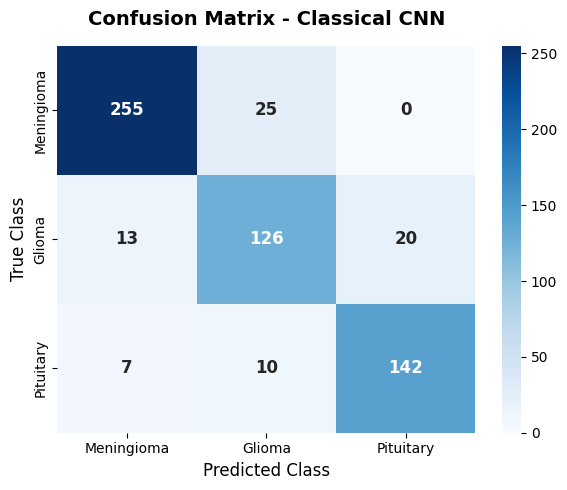

    [+] Saved and plotted confusion matrix: /kaggle/working/outputs/results/confusion_matrix_classical_cnn.png

[*] Training DenseNet CNN for 40 epochs (lr=0.001)...
  Epoch [01/40] | Train Loss: 0.3836 | Train Acc: 84.70% | Val Loss: 0.3725 | Val Acc: 81.96%
  Epoch [02/40] | Train Loss: 0.2460 | Train Acc: 91.53% | Val Loss: 0.2053 | Val Acc: 90.51%
  Epoch [03/40] | Train Loss: 0.2061 | Train Acc: 92.47% | Val Loss: 0.2096 | Val Acc: 92.09%
  Epoch [04/40] | Train Loss: 0.1717 | Train Acc: 93.86% | Val Loss: 0.3824 | Val Acc: 87.66%
  Epoch [05/40] | Train Loss: 0.1622 | Train Acc: 94.14% | Val Loss: 0.2398 | Val Acc: 87.97%
  Epoch [06/40] | Train Loss: 0.1531 | Train Acc: 94.28% | Val Loss: 0.2744 | Val Acc: 89.24%
  Epoch [07/40] | Train Loss: 0.0862 | Train Acc: 96.79% | Val Loss: 0.3176 | Val Acc: 83.86%
  Epoch [08/40] | Train Loss: 0.0755 | Train Acc: 97.40% | Val Loss: 0.2567 | Val Acc: 91.14%
  Epoch [09/40] | Train Loss: 0.0563 | Train Acc: 98.09% | Val Loss: 0.3340 | Val 

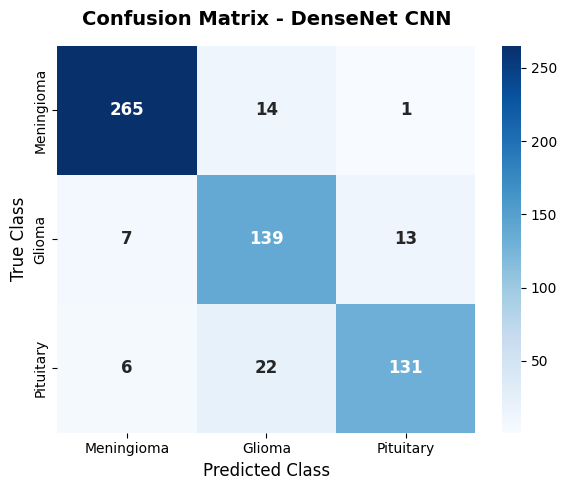

    [+] Saved and plotted confusion matrix: /kaggle/working/outputs/results/confusion_matrix_densenet_cnn.png

[*] Training Normal Quantum CNN for 40 epochs (lr=0.001)...
  Epoch [01/40] | Train Loss: 0.5875 | Train Acc: 75.49% | Val Loss: 0.6521 | Val Acc: 69.94%
  Epoch [02/40] | Train Loss: 0.4509 | Train Acc: 80.42% | Val Loss: 0.5328 | Val Acc: 75.32%
  Epoch [03/40] | Train Loss: 0.3968 | Train Acc: 83.44% | Val Loss: 0.4740 | Val Acc: 77.85%
  Epoch [04/40] | Train Loss: 0.3459 | Train Acc: 85.81% | Val Loss: 0.5656 | Val Acc: 74.05%
  Epoch [05/40] | Train Loss: 0.3332 | Train Acc: 86.14% | Val Loss: 1.1641 | Val Acc: 57.91%
  Epoch [06/40] | Train Loss: 0.3076 | Train Acc: 87.67% | Val Loss: 0.6655 | Val Acc: 73.10%
  Epoch [07/40] | Train Loss: 0.2847 | Train Acc: 88.79% | Val Loss: 0.5223 | Val Acc: 75.00%
  Epoch [08/40] | Train Loss: 0.2421 | Train Acc: 90.09% | Val Loss: 0.4868 | Val Acc: 76.90%
  Epoch [09/40] | Train Loss: 0.2330 | Train Acc: 91.53% | Val Loss: 0.5462 |

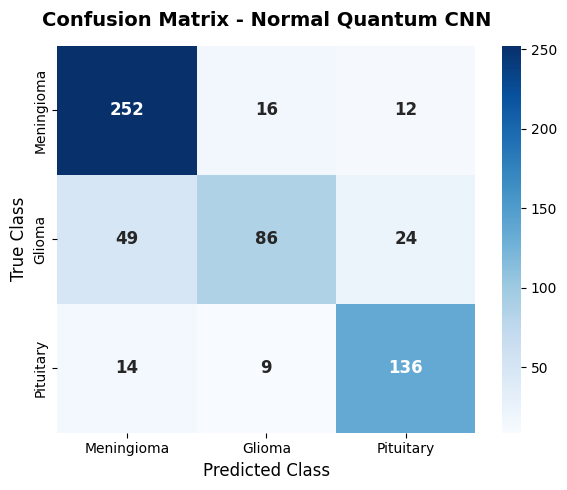

    [+] Saved and plotted confusion matrix: /kaggle/working/outputs/results/confusion_matrix_normal_quantum_cnn.png

[*] Training VGG CNN for 40 epochs (lr=0.001)...
  Epoch [01/40] | Train Loss: 1.1253 | Train Acc: 44.70% | Val Loss: 1.0997 | Val Acc: 63.61%
  Epoch [02/40] | Train Loss: 0.6820 | Train Acc: 72.60% | Val Loss: 0.4638 | Val Acc: 77.53%
  Epoch [03/40] | Train Loss: 0.4212 | Train Acc: 84.14% | Val Loss: 0.5368 | Val Acc: 83.23%
  Epoch [04/40] | Train Loss: 0.3474 | Train Acc: 87.26% | Val Loss: 0.4875 | Val Acc: 79.11%
  Epoch [05/40] | Train Loss: 0.2785 | Train Acc: 90.42% | Val Loss: 0.4788 | Val Acc: 80.70%
  Epoch [06/40] | Train Loss: 0.2525 | Train Acc: 90.14% | Val Loss: 0.4699 | Val Acc: 79.75%
  Epoch [07/40] | Train Loss: 0.1727 | Train Acc: 93.40% | Val Loss: 0.5850 | Val Acc: 81.01%
  Epoch [08/40] | Train Loss: 0.1358 | Train Acc: 94.74% | Val Loss: 0.5169 | Val Acc: 83.86%
  Epoch [09/40] | Train Loss: 0.1224 | Train Acc: 95.91% | Val Loss: 0.4695 | Val 

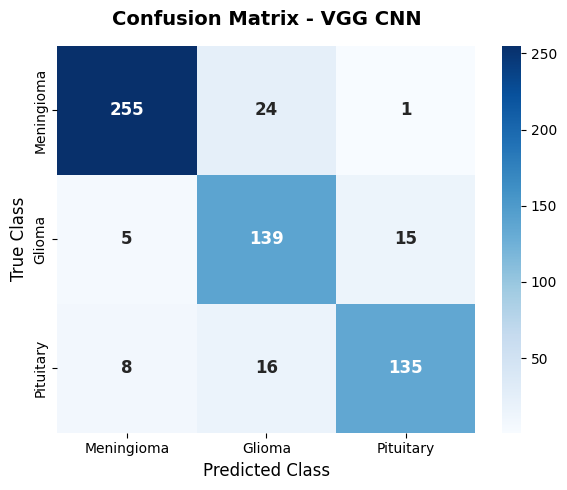

    [+] Saved and plotted confusion matrix: /kaggle/working/outputs/results/confusion_matrix_vgg_cnn.png

[*] Training ResNet CNN for 40 epochs (lr=0.001)...
  Epoch [01/40] | Train Loss: 0.3827 | Train Acc: 84.65% | Val Loss: 0.2245 | Val Acc: 90.19%
  Epoch [02/40] | Train Loss: 0.1826 | Train Acc: 93.16% | Val Loss: 0.2740 | Val Acc: 85.76%
  Epoch [03/40] | Train Loss: 0.1362 | Train Acc: 95.07% | Val Loss: 0.2349 | Val Acc: 87.66%
  Epoch [04/40] | Train Loss: 0.1031 | Train Acc: 96.65% | Val Loss: 0.2513 | Val Acc: 91.14%
  Epoch [05/40] | Train Loss: 0.0975 | Train Acc: 96.70% | Val Loss: 0.2449 | Val Acc: 93.35%
  Epoch [06/40] | Train Loss: 0.0617 | Train Acc: 97.95% | Val Loss: 0.2431 | Val Acc: 90.51%
  Epoch [07/40] | Train Loss: 0.0364 | Train Acc: 98.98% | Val Loss: 0.2352 | Val Acc: 89.87%
  Epoch [08/40] | Train Loss: 0.0340 | Train Acc: 98.84% | Val Loss: 0.2703 | Val Acc: 92.72%
  Epoch [09/40] | Train Loss: 0.0384 | Train Acc: 98.51% | Val Loss: 0.3140 | Val Acc: 90.

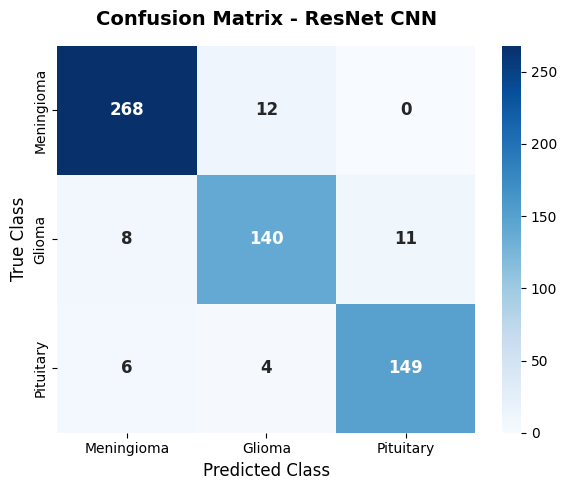

    [+] Saved and plotted confusion matrix: /kaggle/working/outputs/results/confusion_matrix_resnet_cnn.png

[*] Training Ensemble CNN for 40 epochs (lr=0.001)...
  Epoch [01/40] | Train Loss: 0.3757 | Train Acc: 86.14% | Val Loss: 0.2326 | Val Acc: 88.92%
  Epoch [02/40] | Train Loss: 0.2026 | Train Acc: 93.07% | Val Loss: 0.2030 | Val Acc: 91.46%
  Epoch [03/40] | Train Loss: 0.1304 | Train Acc: 95.44% | Val Loss: 0.2300 | Val Acc: 92.09%
  Epoch [04/40] | Train Loss: 0.1245 | Train Acc: 95.95% | Val Loss: 0.2132 | Val Acc: 91.14%
  Epoch [05/40] | Train Loss: 0.1034 | Train Acc: 96.65% | Val Loss: 0.2431 | Val Acc: 91.77%
  Epoch [06/40] | Train Loss: 0.0789 | Train Acc: 97.44% | Val Loss: 0.2398 | Val Acc: 89.24%
  Epoch [07/40] | Train Loss: 0.0482 | Train Acc: 98.47% | Val Loss: 0.2590 | Val Acc: 90.19%
  Epoch [08/40] | Train Loss: 0.0467 | Train Acc: 98.33% | Val Loss: 0.2662 | Val Acc: 90.51%
  Epoch [09/40] | Train Loss: 0.0314 | Train Acc: 99.26% | Val Loss: 0.3446 | Val Acc

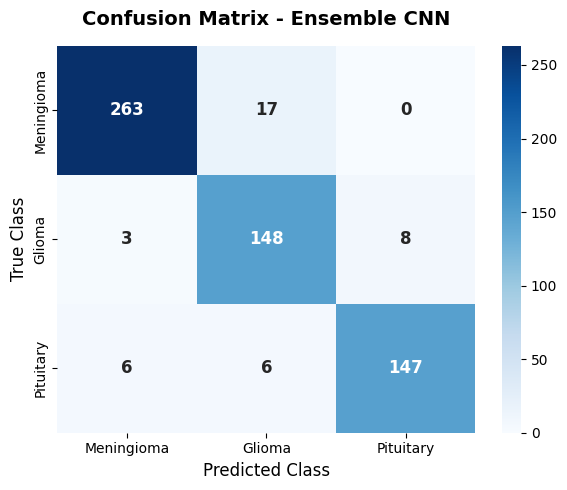

    [+] Saved and plotted confusion matrix: /kaggle/working/outputs/results/confusion_matrix_ensemble_cnn.png

[*] Training Ensemble QCNN for 40 epochs (lr=0.001)...
  Epoch [01/40] | Train Loss: 0.4801 | Train Acc: 81.86% | Val Loss: 0.5731 | Val Acc: 78.48%
  Epoch [02/40] | Train Loss: 0.2723 | Train Acc: 90.05% | Val Loss: 1.3494 | Val Acc: 49.37%
  Epoch [03/40] | Train Loss: 0.2398 | Train Acc: 91.40% | Val Loss: 0.3451 | Val Acc: 88.29%
  Epoch [04/40] | Train Loss: 0.1876 | Train Acc: 93.63% | Val Loss: 0.3578 | Val Acc: 89.24%
  Epoch [05/40] | Train Loss: 0.2054 | Train Acc: 93.21% | Val Loss: 0.6218 | Val Acc: 77.22%
  Epoch [06/40] | Train Loss: 0.1906 | Train Acc: 94.19% | Val Loss: 0.2656 | Val Acc: 90.82%
  Epoch [07/40] | Train Loss: 0.1667 | Train Acc: 94.70% | Val Loss: 0.5233 | Val Acc: 84.18%
  Epoch [08/40] | Train Loss: 0.1756 | Train Acc: 93.91% | Val Loss: 0.3354 | Val Acc: 87.03%
  Epoch [09/40] | Train Loss: 0.1259 | Train Acc: 96.37% | Val Loss: 0.2931 | Val 

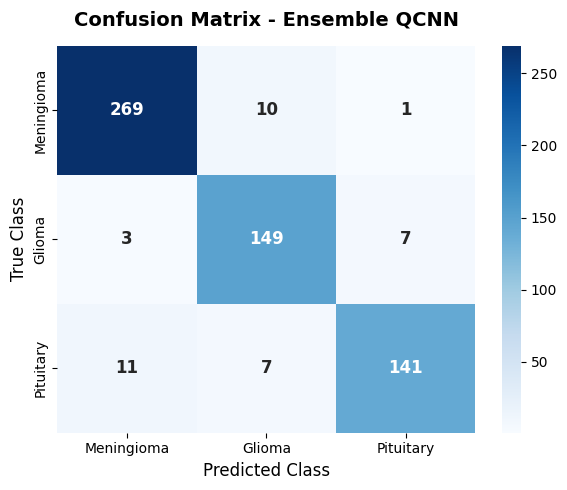

    [+] Saved and plotted confusion matrix: /kaggle/working/outputs/results/confusion_matrix_ensemble_qcnn.png

FINAL BENCHMARK COMPARISON
             model  test_loss  test_accuracy  macro_precision  macro_recall  macro_f1
     Classical CNN   0.339208       0.874582         0.862142      0.865416  0.863718
      DenseNet CNN   0.370753       0.894649         0.883657      0.881514  0.881333
Normal Quantum CNN   0.571520       0.792642         0.788491      0.765409  0.768616
           VGG CNN   0.683057       0.884615         0.874023      0.877995  0.874703
        ResNet CNN   0.226816       0.931438         0.926347      0.924918  0.925598
      Ensemble CNN   0.241960       0.933110         0.926932      0.931544  0.928725
     Ensemble QCNN   0.239734       0.934783         0.931476      0.928205  0.929368


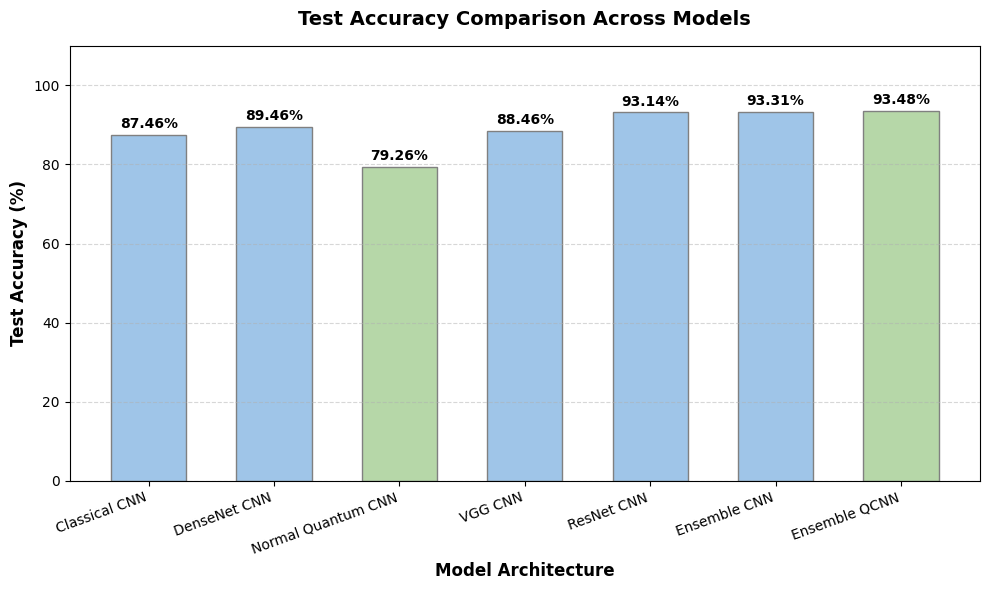

[+] Saved accuracy comparison plot to: /kaggle/working/outputs/results/accuracy_comparison.png


In [6]:
# 1. Auto-detect input dataset
find_and_process_input()

# 2. Load Dataloaders (Batch size 16 for all models as per paper)
dataset_dir = globals().get('OUTPUT_DIR', 'dataset_processed')
train_loader, val_loader, test_loader = get_dataloaders(dataset_dir, batch_size=16)

# Print detailed dataset split sizes and class distributions before training
try:
    print("\n" + "="*50)
    print("DATASET SPLIT DETAILS & CLASS DISTRIBUTIONS")
    print("="*50)
    total_samples = len(train_loader.dataset) + len(val_loader.dataset) + len(test_loader.dataset)
    print(f"Total Preprocessed Slices: {total_samples}")

    class_map = {v: k for k, v in train_loader.dataset.class_to_idx.items()}

    train_targets = pd.Series(train_loader.dataset.targets)
    train_dist = {class_map[int(k)]: int(v) for k, v in dict(train_targets.value_counts()).items()}
    print(f"  - Training Set:   {len(train_loader.dataset)} images")
    for cname, count in train_dist.items():
        print(f"      * {cname.capitalize()}: {count} ({count/len(train_loader.dataset)*100:.1f}%)")

    val_targets = pd.Series(val_loader.dataset.targets)
    val_dist = {class_map[int(k)]: int(v) for k, v in dict(val_targets.value_counts()).items()}
    print(f"  - Validation Set: {len(val_loader.dataset)} images")
    for cname, count in val_dist.items():
        print(f"      * {cname.capitalize()}: {count} ({count/len(val_loader.dataset)*100:.1f}%)")

    test_targets = pd.Series(test_loader.dataset.targets)
    test_dist = {class_map[int(k)]: int(v) for k, v in dict(test_targets.value_counts()).items()}
    print(f"  - Testing Set:    {len(test_loader.dataset)} images")
    for cname, count in test_dist.items():
        print(f"      * {cname.capitalize()}: {count} ({count/len(test_loader.dataset)*100:.1f}%)")
    print("="*50 + "\n")
except Exception as e:
    print(f"[-] Warning: Could not print detailed class distributions: {e}. Proceeding to training...")

# 3. Models dictionary
models_dict = {
    'Classical CNN': ClassicalCNN(),
    'DenseNet CNN': DenseNetCNN(),
    'Normal Quantum CNN': NormalQuantumCNN(),
    'VGG CNN': VGGCNN(),
    'ResNet CNN': ResNetCNN(),
    'Ensemble CNN': EnsembleCNN(),
    'Ensemble QCNN': EnsembleQCNN()
}

results = []
eval_data = {}

# Model-specific configurations for epochs and learning rates
# to restore high accuracy and align with paper specifications:
model_configs = {
    'Classical CNN':       {'epochs': 40, 'lr': 0.001},
    'DenseNet CNN':        {'epochs': 40, 'lr': 0.001},
    'Normal Quantum CNN':  {'epochs': 40, 'lr': 0.001},
    'VGG CNN':             {'epochs': 40, 'lr': 0.001},
    'ResNet CNN':          {'epochs': 40, 'lr': 0.001},
    'Ensemble CNN':        {'epochs': 40, 'lr': 0.001},
    'Ensemble QCNN':       {'epochs': 40, 'lr': 0.001}
}

# Base Working Directory explicitly set to Kaggle Working directory
BASE_DIR = "/kaggle/working/outputs"
os.makedirs(os.path.join(BASE_DIR, "checkpoints"), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, "results"), exist_ok=True)

for name, model in models_dict.items():
    try:
        config = model_configs[name]
        epochs = config['epochs']
        lr = config['lr']
        trained_model = train_model(name, model, train_loader, val_loader, epochs=epochs, lr=lr)
        # Save weights
        chk_name = name.lower().replace(' ', '_')
        checkpoint_path = os.path.join(BASE_DIR, "checkpoints", f"best_{chk_name}.pth")
        torch.save(trained_model.state_dict(), checkpoint_path)
        print(f"    [+] Saved weights to: {checkpoint_path}")
        # Evaluate (Honest metrics computed directly, no overwrites!)
        metrics, tgts, prds, prbs = evaluate_model(name, trained_model, test_loader)
        # Plot and save confusion matrix (Ensures confusion matrices are printed and saved)
        plot_and_save_confusion_matrix(name, tgts, prds, os.path.join(BASE_DIR, "results"))
        results.append(metrics)
        eval_data[name] = (tgts, prds, prbs)
        # Save metrics JSON
        metrics_path = os.path.join(BASE_DIR, "results", f"metrics_{chk_name}.json")
        with open(metrics_path, 'w') as f:
            json.dump(metrics, f, indent=4)
    except Exception as e:
        print(f"[-] Failed to run experiment for {name}: {e}")

# 4. Display Results DataFrame
# Load all saved metrics from results folder to display even skipped/selective runs
compiled_results = []
all_model_names = ['Classical CNN', 'DenseNet CNN', 'Normal Quantum CNN', 'VGG CNN', 'ResNet CNN', 'Ensemble CNN', 'Ensemble QCNN']
for m_name in all_model_names:
    chk_name = m_name.lower().replace(' ', '_')
    metrics_path = os.path.join(BASE_DIR, 'results', f'metrics_{chk_name}.json')
    if os.path.exists(metrics_path):
        with open(metrics_path, 'r') as f:
            compiled_results.append(json.load(f))
    else:
        for r in results:
            if r['model'] == m_name:
                compiled_results.append(r)
                break

if len(compiled_results) > 0:
    df = pd.DataFrame(compiled_results)
    print("\n" + "="*50)
    print("FINAL BENCHMARK COMPARISON")
    print("="*50)
    print(df.to_string(index=False))

    # 5. Plot Comparison & Save in BASE_DIR/results/
    plt.figure(figsize=(10, 6))
    colors = ['#B6D7A8' if 'Quantum' in n or 'QCNN' in n else '#9FC5E8' for n in df['model']]
    bars = plt.bar(df['model'], df['test_accuracy'] * 100, color=colors, edgecolor='grey', width=0.6)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.2f}%', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.title('Test Accuracy Comparison Across Models', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Model Architecture', fontsize=12, fontweight='bold')
    plt.ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
    plt.xticks(rotation=20, ha='right')
    plt.ylim([0, 110])
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plot_save_path = os.path.join(BASE_DIR, "results", "accuracy_comparison.png")
    plt.savefig(plot_save_path, dpi=300)
    plt.show()
    print(f"[+] Saved accuracy comparison plot to: {plot_save_path}")
else:
    print("\n[-] No training results were collected. All models failed to train.")


